## **MCF7 - Drop Sequence - EDA**

### **Introduction**

<p style="font-size:15px; line-height:1.6;">We move on to exploring the dataset for the MCF7 cell line with the DropSeq technology. This type of technique is ideal for analyzing large inputs of cells/samples via droplet microfluidics.</P>

#### **Structure of the file**

**EDA (Exploratory Data Analysis)**
- General Information

- Missing Values
- Duplicate Genes
- Cells' correlation
- Sparsity 
- Data Distribution 

#### **Libraries**

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.stats import kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
np.random.seed(42)

### **Exploratory Data Analysis**

#### **General Information**

<p style="font-size:15px; line-height:1.6;">We import the dataset. Note that the file provided for the DropSeq has been already filtered and normalized, so no additional transformations are required. Our goal is therefore to simply explore the dataset.</p>

In [43]:
filtered = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/MCF7_Drop_Filtered_Normalised_3000_Data_train.txt",delimiter="\ ",engine='python',index_col=0)

In [44]:
print("Dataframe dimensions:", np.shape(filtered))
print("First column: ", filtered.iloc[ : , 0])
filtered.shape
list(filtered.columns)

Dataframe dimensions: (3000, 21626)
First column:  "MALAT1"       1
"MT-RNR2"      0
"NEAT1"        0
"H1-5"         0
"TFF1"         4
              ..
"BRWD1-AS2"    0
"RPS19BP1"     0
"AUNIP"        0
"TNK2"         0
"SUDS3"        0
Name: "AAAAACCTATCG_Normoxia", Length: 3000, dtype: int64


['"AAAAACCTATCG_Normoxia"',
 '"AAAACAACCCTA_Normoxia"',
 '"AAAACACTCTCA_Normoxia"',
 '"AAAACCAGGCAC_Normoxia"',
 '"AAAACCTAGCTC_Normoxia"',
 '"AAAACCTCCGGG_Normoxia"',
 '"AAAACTCGTTGC_Normoxia"',
 '"AAAAGAGCTCTC_Normoxia"',
 '"AAAAGCTAGGCG_Normoxia"',
 '"AAAATCGCATTT_Normoxia"',
 '"AAAATCTACATA_Normoxia"',
 '"AAAATGGCTCTC_Normoxia"',
 '"AAAATGGGCCGG_Normoxia"',
 '"AAACAAACTCAA_Normoxia"',
 '"AAACAACGAATT_Normoxia"',
 '"AAACAATGAGGT_Normoxia"',
 '"AAACACGCCGCG_Normoxia"',
 '"AAACAGCACGAC_Normoxia"',
 '"AAACATACCCGT_Normoxia"',
 '"AAACATGGATCC_Normoxia"',
 '"AAACATTAGAAT_Normoxia"',
 '"AAACCAACCGGT_Normoxia"',
 '"AAACCAGCCTGG_Normoxia"',
 '"AAACCAGGCTCT_Normoxia"',
 '"AAACCAGGGCAC_Normoxia"',
 '"AAACCCGATTTC_Normoxia"',
 '"AAACCGACGTCG_Normoxia"',
 '"AAACCGCTGCAT_Normoxia"',
 '"AAACCGTCCCGC_Normoxia"',
 '"AAACCGTTAGCC_Normoxia"',
 '"AAACCGTTGGGG_Normoxia"',
 '"AAACCGTTTCTT_Normoxia"',
 '"AAACCTAGGAGA_Normoxia"',
 '"AAACCTATTGTC_Normoxia"',
 '"AAACCTCCACGA_Normoxia"',
 '"AAACCTGAGGGA_Norm

In [45]:
print("Dataframe indexes: ", filtered.index)
print("Dataframe columns: ", filtered.columns)

Dataframe indexes:  Index(['"MALAT1"', '"MT-RNR2"', '"NEAT1"', '"H1-5"', '"TFF1"', '"MT-RNR1"',
       '"H4C3"', '"GDF15"', '"KRT81"', '"MT-CO3"',
       ...
       '"MROH1"', '"SKIDA1"', '"MICALL1"', '"RARG"', '"MYO1F"', '"BRWD1-AS2"',
       '"RPS19BP1"', '"AUNIP"', '"TNK2"', '"SUDS3"'],
      dtype='object', length=3000)
Dataframe columns:  Index(['"AAAAACCTATCG_Normoxia"', '"AAAACAACCCTA_Normoxia"',
       '"AAAACACTCTCA_Normoxia"', '"AAAACCAGGCAC_Normoxia"',
       '"AAAACCTAGCTC_Normoxia"', '"AAAACCTCCGGG_Normoxia"',
       '"AAAACTCGTTGC_Normoxia"', '"AAAAGAGCTCTC_Normoxia"',
       '"AAAAGCTAGGCG_Normoxia"', '"AAAATCGCATTT_Normoxia"',
       ...
       '"TTTTACAGGATC_Hypoxia"', '"TTTTACCACGTA_Hypoxia"',
       '"TTTTATGCTACG_Hypoxia"', '"TTTTCCAGACGC_Hypoxia"',
       '"TTTTCGCGCTCG_Hypoxia"', '"TTTTCGCGTAGA_Hypoxia"',
       '"TTTTCGTCCGCT_Hypoxia"', '"TTTTCTCCGGCT_Hypoxia"',
       '"TTTTGTTCAAAG_Hypoxia"', '"TTTTTTGTATGT_Hypoxia"'],
      dtype='object', length=21626)


In [46]:
filtered.head() 

,"""AAAAACCTATCG_Normoxia""","""AAAACAACCCTA_Normoxia""","""AAAACACTCTCA_Normoxia""","""AAAACCAGGCAC_Normoxia""","""AAAACCTAGCTC_Normoxia""","""AAAACCTCCGGG_Normoxia""","""AAAACTCGTTGC_Normoxia""","""AAAAGAGCTCTC_Normoxia""","""AAAAGCTAGGCG_Normoxia""","""AAAATCGCATTT_Normoxia""",...,"""TTTTACAGGATC_Hypoxia""","""TTTTACCACGTA_Hypoxia""","""TTTTATGCTACG_Hypoxia""","""TTTTCCAGACGC_Hypoxia""","""TTTTCGCGCTCG_Hypoxia""","""TTTTCGCGTAGA_Hypoxia""","""TTTTCGTCCGCT_Hypoxia""","""TTTTCTCCGGCT_Hypoxia""","""TTTTGTTCAAAG_Hypoxia""","""TTTTTTGTATGT_Hypoxia"""
"""MALAT1""",1,3,3,6,4,5,1,13,3,3,...,0,2,1,0,1,0,1,0,0,4
"""MT-RNR2""",0,0,0,2,0,0,2,1,7,0,...,0,0,0,0,0,0,0,0,0,0
"""NEAT1""",0,0,0,0,0,2,0,1,2,0,...,0,0,0,0,0,0,0,0,0,0
"""H1-5""",0,0,0,0,0,2,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
"""TFF1""",4,1,1,1,0,0,0,2,0,1,...,2,3,8,0,0,3,4,2,6,0


<p style="font-size:15px; line-height:1.6;">From the above inspections, this dataset is substantially larger, when compared to the Smart Sequence experiment. It has 3000 rows and 21626 columns, again corresponding to genes and cells and thus, being a gene expression matrix. 
Here, genes are identified by their gene symbols, but now cells are represented by a short DNA barcode that is specific to each cell, and with a label (i.e., Hypoxia or Normoxia) that indicates the condition of the cell.</p>

<p style="font-size:15px; line-height:1.6;">We remove the quotations and as previously done, we transpose the matrix so that its rows are now representing the cells of the dataset.</p>

In [47]:
def remove_double_quotes(word):
    return word.replace('"', '')

In [48]:
filtered = filtered.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in filtered.columns})
filtered = filtered.T
filtered = filtered.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in filtered.columns})
print("Dataframe dimesions:", np.shape(filtered))

Dataframe dimesions: (21626, 3000)


In [49]:
filtered.dtypes.unique() 

array([dtype('int64')], dtype=object)

In [50]:
numeric_columns = filtered.select_dtypes(include=[np.number]).columns
all_numeric = len(numeric_columns) == len(filtered.columns)
print(all_numeric)

True


<p style="font-size:15px; line-height:1.6;">As shown above, the type of data that we have is int64, which ensures that the values are numeric and thus, suitable for computations.</p>

**Target Count**

<p style="font-size:15px; line-height:1.6;">It is important that we count how many Normoxic and Hypoxic cells there are in our dataset. This is because we want a balanced dataset with respect to the two conditions as an imbalanced dataset could negatively affect the training phase and lead to a biased model.</p>

12705 8921


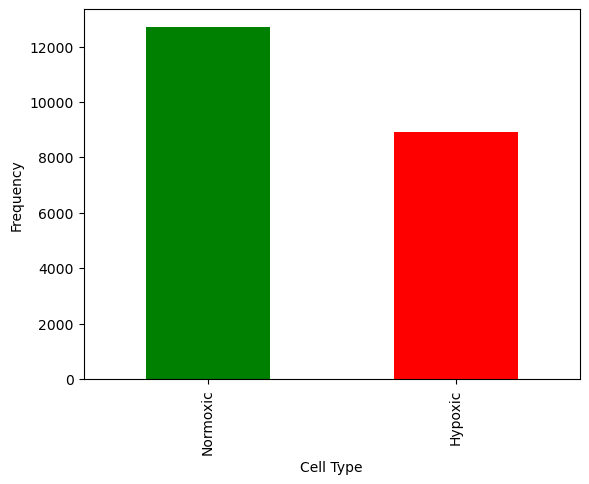

In [51]:
normoxic_cells = filtered.T.columns.str.contains('Norm', case=False, na=False).sum()
hypoxic_cells = filtered.T.columns.str.contains('Hypo', case=False, na=False).sum()

print(normoxic_cells, hypoxic_cells)

s = pd.Series({"Normoxic": normoxic_cells, "Hypoxic": hypoxic_cells})
ax = s.plot(kind='bar', color=['green', 'red'])
plt.xlabel("Cell Type")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

<p style="font-size:15px; line-height:1.6;">In contrast to the MFC7 dataset, there is a moderate class imbalance, with around 58% of Normoxic versus 42% hypoxic cells. To reduce the impact of such difference in cells, we used a stratified train-test split as well as class weights in classifiers. Also, we evaluated the model based on several metrics such as accuracy, F1-score, AUC, and more, to provide a better understanding of how well the models classify both classes.</p> 

We, now, compute the summary statistics for each gene:

In [52]:
table = filtered.describe()
table

,MALAT1,MT-RNR2,NEAT1,H1-5,TFF1,MT-RNR1,H4C3,GDF15,KRT81,MT-CO3,...,MROH1,SKIDA1,MICALL1,RARG,MYO1F,BRWD1-AS2,RPS19BP1,AUNIP,TNK2,SUDS3
count,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,...,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000,21626.000000
mean,3.634791,0.850458,0.136086,0.368862,1.799362,0.291362,1.730972,0.011884,0.026912,0.105105,...,0.008046,0.002035,0.003930,0.016138,0.000971,0.000832,0.034172,0.002405,0.003884,0.088042
std,6.837353,1.721088,0.643060,0.953887,2.486034,0.740664,2.328460,0.189425,0.233430,0.387558,...,0.092892,0.048995,0.065461,0.131046,0.032598,0.028839,0.200548,0.053491,0.064395,0.323733
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,1.000000,0.000000,0.000000,3.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,175.000000,32.000000,23.000000,22.000000,46.000000,16.000000,44.000000,20.000000,17.000000,5.000000,...,2.000000,3.000000,2.000000,3.000000,2.000000,1.000000,4.000000,3.000000,2.000000,3.000000


<p style="font-size:15px; line-height:1.6;">A brief inspection of the summary statistics reveals characteristics that are consistent with those observed in a Gene Expression Matrix. 

<p style="font-size:15px; line-height:1.6;">The low mean and median values indicate that most genes are not highly expressed across all samples. This can be explained by the sparsity of the dataset, where the majority of the entries are equal to 0. Also, the fact that the standard deviation is higher than the mean reveal that some genes are highly expressed in a small set of cells. 

**Other Information**

In [53]:
gene_sums = filtered.sum(axis=0)

min_gene = gene_sums.idxmin()
print("Gene with the least total expression:", min_gene)
print("Total expression:", gene_sums.min())

max_gene = gene_sums.idxmax()
print("Gene with the most total expression:", max_gene)
print("Total expression:", gene_sums.max())

print("Global max is:", table.loc["max"].max())
print("Global min is:", table.loc["min"].min())

min_expressed_gene = filtered.T.sum(axis = 0).idxmin()
print("\nLeast expressed cell: {}\nProduced genes:{}\nUnique genes:{}\n".format(min_expressed_gene, filtered.T.sum(axis = 0)[min_expressed_gene], filtered.T.astype(bool).sum(axis = 0).min()))

max_expressed_gene = filtered.T.sum(axis = 0).idxmax()
print("Most expressed cell: {}\nProduced genes:{}\nUnique genes:{}".format(max_expressed_gene, filtered.T.sum(axis = 0)[max_expressed_gene], filtered.T.astype(bool).sum(axis = 0).max()))

Gene with the least total expression: FOXP3
Total expression: 8
Gene with the most total expression: MALAT1
Total expression: 78606
Global max is: 175.0
Global min is: 0.0

Least expressed cell: CTGCCTATGGGC_Normoxia
Produced genes:45
Unique genes:21

Most expressed cell: GAAGTGAGGGCC_Hypoxia
Produced genes:245
Unique genes:189


In [54]:
normoxic_cells = filtered.index.str.contains('Norm', case=False, na=False)
hypoxic_cells = filtered.index.str.contains('Hypo', case=False, na=False)

codified_genes_normoxia = np.count_nonzero(filtered.loc[normoxic_cells, :].values)
codified_genes_hypoxia  = np.count_nonzero(filtered.loc[hypoxic_cells, :].values)

print("Genes in normoxic cells:", codified_genes_normoxia)
print("Genes in hypoxic cells:", codified_genes_hypoxia)

Genes in normoxic cells: 953760
Genes in hypoxic cells: 649096


#### **Missing Values - Duplicate Genes**

In [55]:
filtered.isna().sum().sum()

0

There are no missing values.

In [56]:
duplicate_data = filtered.T[filtered.T.duplicated()]
print("Number of duplicate genes:", duplicate_data.shape[0], "over", filtered.T.shape[0])
print("Percentage of duplicate genes:", (duplicate_data.shape[0] * 100) / (filtered.T.shape[0]), "%")

Number of duplicate genes: 0 over 3000
Percentage of duplicate genes: 0.0 %


There are no duplicates.

#### **Correlation between Cells**

<p style="font-size:15px; line-height:1.6;">Now, we check the correlation between gene expression profiles of different samples. Just like with SmartSeq, we will use Pearson's Correlation Coefficient for this analysis and a heatmap for visualization.

<p style="font-size:15px; line-height:1.6;">Since DropSeq is very large, we computed the correlation matrix on a subset of 50 randomly selected cells.

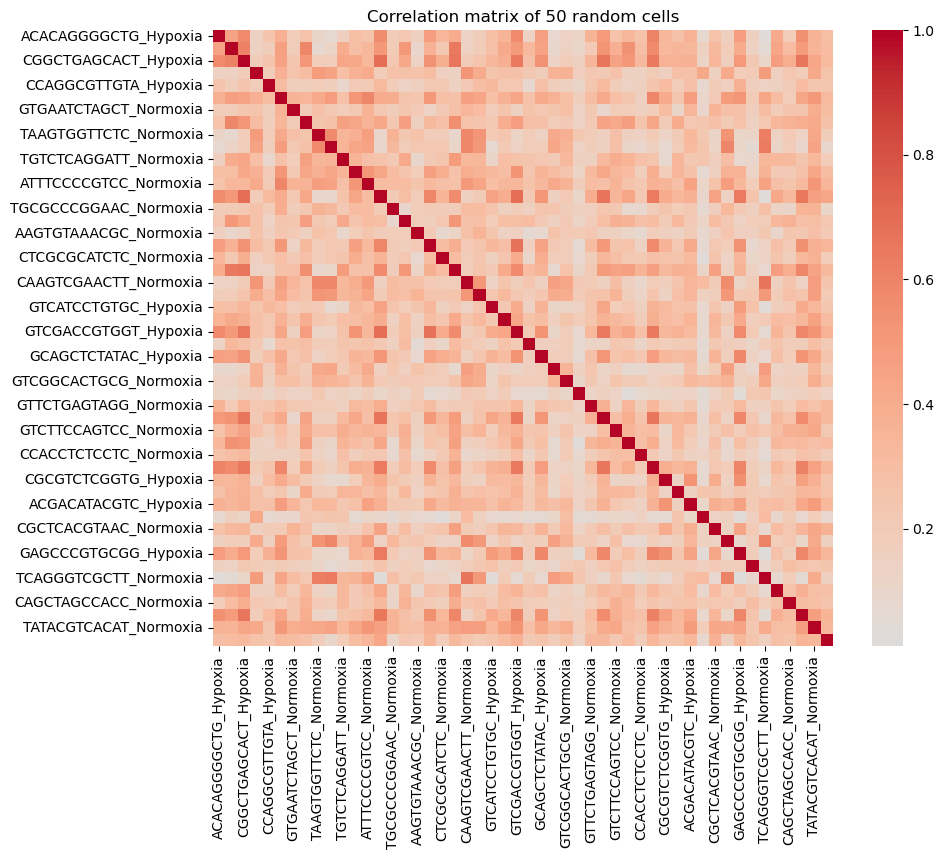

Average correlation: 0.28653000158563574
Minimum correlation: 0.01138520991314064


In [57]:
n_cells = 50   

random_rows = list(range(filtered.shape[0]))
random.shuffle(random_rows)

random_rows = random_rows[:n_cells]

drop_small = filtered.iloc[random_rows, :]
c = drop_small.T.corr()
plt.figure(figsize=(10,8))

sns.heatmap(c, cmap="coolwarm", center=0)

plt.title(f"Correlation matrix of {n_cells} random cells")

plt.show()

print("Average correlation:", c.values.mean())
print("Minimum correlation:", c.values.min())

<p style="font-size:15px; line-height:1.6;"> The correlation matrix shows that most cells exhibit moderate positive correlations with one another (approximately 30%). This suggests that the cells share simiral over gene expression patterns, while still maintaining their biological differences. In addition, the presence of some lower correlation values shows that certain cells have distinct expression profiles, which may reflect the genuine biological differences between hypoxic and normoxic conditions.

#### **Sparsity**

<p style="font-size:15px; line-height:1.6;">It is important to get an idea of the sparsity of this data. Taking into account that our dataset is a Gene Expression Matrix, we expect it to be sparse.

In [58]:
n_zeros = np.count_nonzero(filtered==0)                # count the number of elements in the boolean mask (data == 0) that are true, so the number of 0 elements
print('Number of 0 values in the matrix:', n_zeros)

sp = n_zeros / filtered.size
print('Sparsity index:', sp*100, '%')

Number of 0 values in the matrix: 63275144
Sparsity index: 97.52943062363205 %


<p style="font-size:15px; line-height:1.6;">The sparsity index is approximately 97.5%, meaning that the vast majority of the cell entries in the matrix are 0. This reflects the fact that many genes are inactive or expressed at very low levels in individual cells. 

Now, we visualize the sparsity of the matrix, using a heatmap.

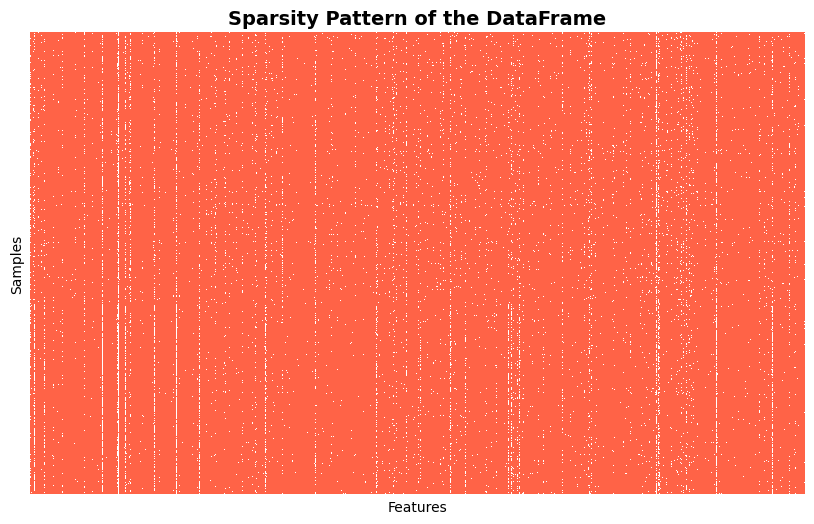

In [59]:
zeroes_mask = filtered == 0
colors = ["#FFFFFF", "#FF6347"] 
plt.figure(figsize=(10, 6))
sns.heatmap(zeroes_mask, cmap=sns.color_palette(colors), cbar=False, xticklabels=False, yticklabels=False)
plt.title('Sparsity Pattern of the DataFrame', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=10)
plt.ylabel('Samples', fontsize=10)
plt.show()

<p style="font-size:15px; line-height:1.6;">The heatmap further confirms that this dataset is extremely sparse, and even more sparse than the SmartSeq data. Despite that most of the matrix is composed of zero entries, the non-zero entries are distributed throughout the dataset, suggesting that meaningful biological information is preserved.

#### **Data Distribution**

**Skewness of Genes**

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


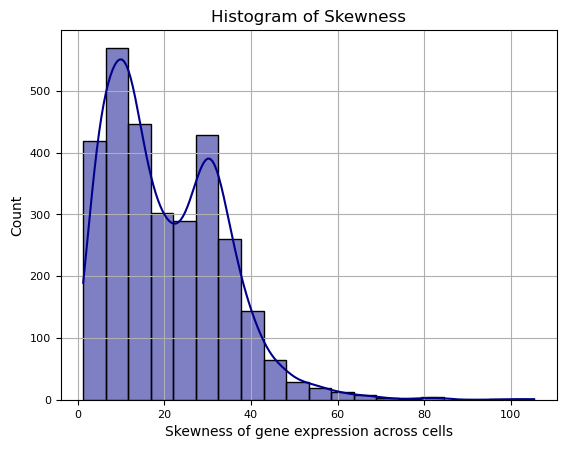

Mean Skewness: 20.47306818949526


In [60]:
unf_skew_genes = [skew(filtered[col]) for col in filtered.columns]
sns.histplot(unf_skew_genes, kde=True, color='darkblue', bins=20)

plt.title("Histogram of Skewness", fontsize=12)
plt.xlabel("Skewness of gene expression across cells", fontsize=10)
plt.ylabel("Count", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True)
plt.show()
print("Mean Skewness:", np.mean(unf_skew_genes))


<p style="font-size:15px; line-height:1.6;"> The histogram shows that most genes have strongly positive skewness of approximately 21% (towards the right). This indicates that most expression values are small or equal to zero, while some cells exhibit very high expression levels for certain genes. Such behavior is expected due to the sparse nature of gene expression datasets.

 **Kurtosis**

Similarly to the analysis of skewness:

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


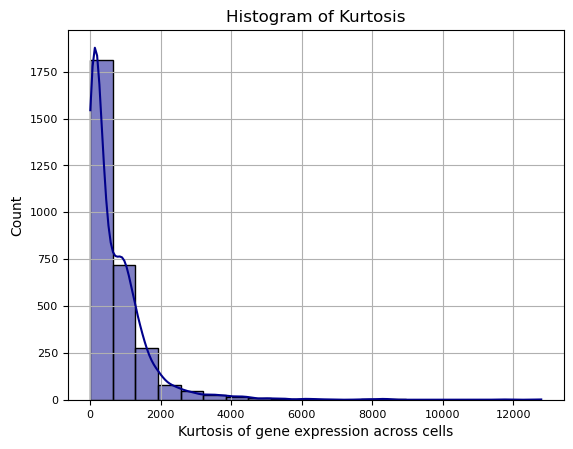

Mean Kurtosis: 698.512088423201


In [61]:
unf_kurt_genes = [kurtosis(filtered[col]) for col in filtered.columns]

sns.histplot(unf_kurt_genes, kde=True, color='darkblue', bins=20)

plt.title("Histogram of Kurtosis", fontsize=12)
plt.xlabel("Kurtosis of gene expression across cells", fontsize=10)
plt.ylabel("Count", fontsize=10)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.grid(True)
plt.show()
print("Mean Kurtosis:", np.mean(unf_kurt_genes))

<p style="font-size:15px; line-height:1.6;">As of kurtosis, most genes have high positive kurtosis values, with an average kurtosis of approximately 698. This indicates that the gene expression distributions are characterized by heavy tails and the presence of extreme values. Such behavior is typical for this type of datasets, as most genes are weakly or not expressed. This long right tail confirms the existence of highly variable genes.